In [1]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
client = MongoClient('mongodb://localhost:27017')

db = client["sample_supplies"]

collection = db["sales"]

print(f"total: {collection.count_documents({}):,}")

total: 5,000


# Q15: What is the average selling price of each product?

In [19]:
#code for Query 15
from pprint import pprint

pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name",
            "avg_sp": {
                "$avg": {"$toDouble": "$items.price"}
            }
        }
    },
    {
        "$sort" : {"avg_sp": -1}
    }
]

avg = list(collection.aggregate(pipeline))
#pprint(avg)

avg_df = pd.DataFrame(avg)
avg_df.rename(columns={"_id":"product name","avg_sp":"Average salling price"},inplace = True)

avg_df

print("Highest Average Selling Price Product:")
print(avg_df.iloc[0])

Highest Average Selling Price Product:
product name                 laptop
Average salling price    992.152008
Name: 0, dtype: object


## Code for Visualization

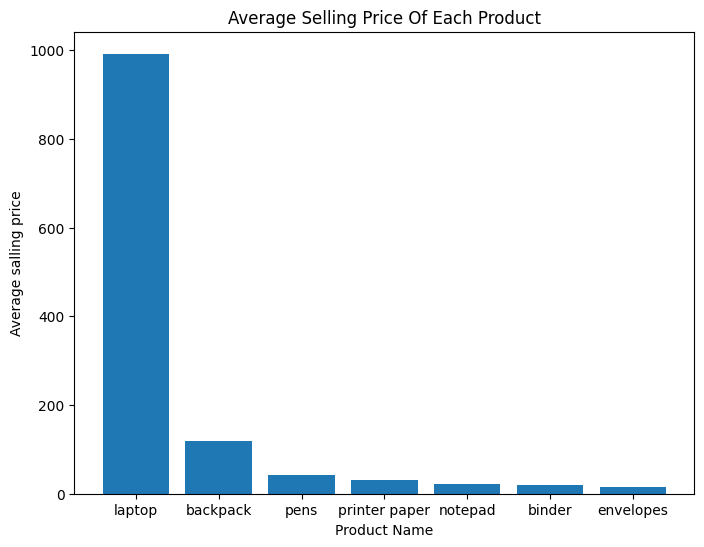

In [18]:
plt.figure(figsize=(8, 6))

plt.bar(avg_df["product name"],avg_df["Average salling price"])
plt.title("Average Selling Price Of Each Product")

plt.xlabel("Product Name")
plt.ylabel("Average salling price")

plt.show()